## Imports

In [14]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import plotly.express as px
import re

## Read Data

In [10]:
finnhub_data = pd.read_csv('Data/finnhub_clean.csv')

## Quick schema check

In [11]:
print('finnhub shape:', finnhub_data.shape)
print('\nfinnhub columns:', list(finnhub_data.columns))
display(finnhub_data[['stock', 'headline', 'date_only']].head(2))

finnhub shape: (5006, 4)

finnhub columns: ['stock', 'headline', 'date', 'date_only']


,stock,headline,date_only
0,JPM,"Inside ‘Project Eagle,’ JPMorgan’s High-Wire A...",2026-03-28
1,JPM,"AI Schism Grips Washington as Tech, Labor Vie ...",2026-03-28


## Exploratory data analysis

,missing_count
stock,0
headline,0
date_only,0


Date range combined: 2024-09-17 -> 2026-03-28
Unique stocks: 27


,n_records
stock,
BCS,248
MUFG,248
DB,248
JPM,247
GS,246
SAN,243
HSBC,242
MS,242
BAC,241


,headline_len_stats
count,5006.000000
mean,76.849780
std,35.077129
min,10.000000
25%,59.000000
50%,70.000000
75%,86.000000
max,485.000000


,date_only,n_records
334,2026-03-19,150
335,2026-03-20,115
336,2026-03-21,35
337,2026-03-22,20
338,2026-03-23,98
339,2026-03-24,108
340,2026-03-25,127
341,2026-03-26,116
342,2026-03-27,102
343,2026-03-28,35


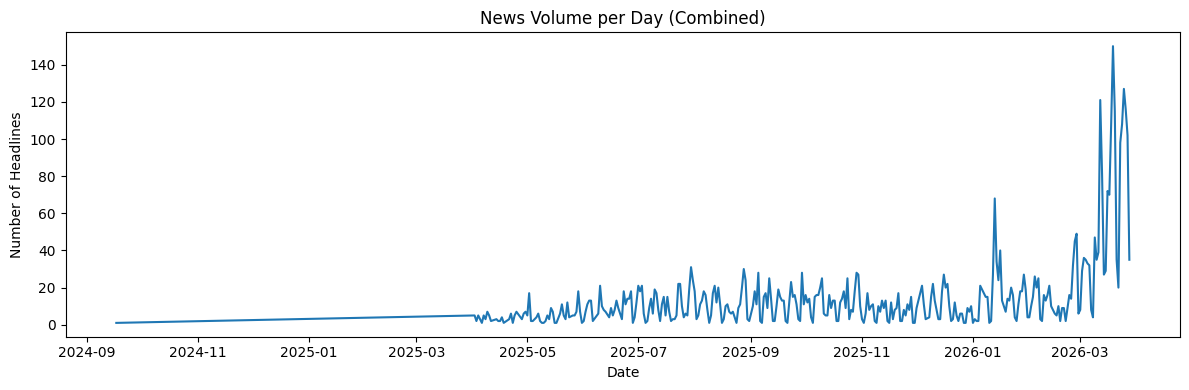

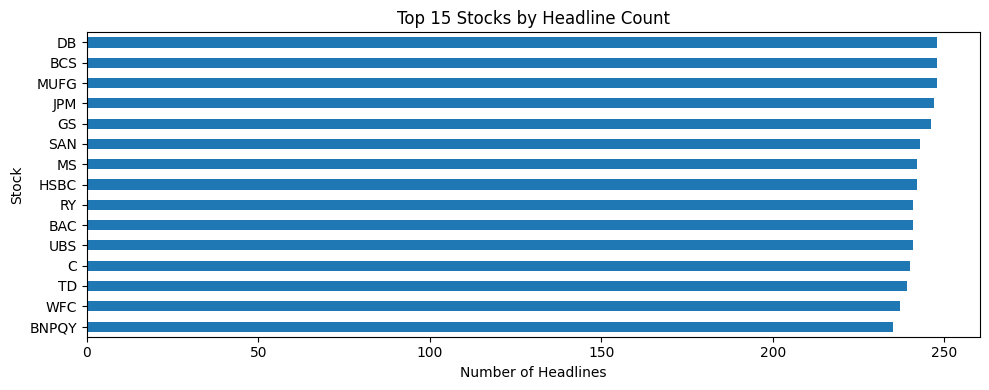

In [12]:
# quality checks
display(finnhub_data[['stock', 'headline', 'date_only']].isna().sum().to_frame('missing_count'))
print('Date range combined:', finnhub_data['date_only'].min(), '->', finnhub_data['date_only'].max())
print('Unique stocks:', finnhub_data['stock'].nunique())

# top stocks
top_stocks = finnhub_data['stock'].value_counts().head(15)
display(top_stocks.rename_axis('stock').to_frame('n_records'))

# headline length
finnhub_data['headline_len'] = finnhub_data['headline'].str.len()
display(finnhub_data['headline_len'].describe().to_frame('headline_len_stats'))

# daily volume
daily_counts = finnhub_data.groupby('date_only').size().rename('n_records').reset_index()
display(daily_counts.tail(10))

try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 4))
    plt.plot(pd.to_datetime(daily_counts['date_only']), daily_counts['n_records'])
    plt.title('News Volume per Day (Combined)')
    plt.xlabel('Date')
    plt.ylabel('Number of Headlines')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    top_stocks.sort_values().plot(kind='barh')
    plt.title('Top 15 Stocks by Headline Count')
    plt.xlabel('Number of Headlines')
    plt.ylabel('Stock')
    plt.tight_layout()
    plt.show()
except Exception as error:
    print('Plotting skipped:', error)

## Wordcloud


Generating word cloud for summaries...


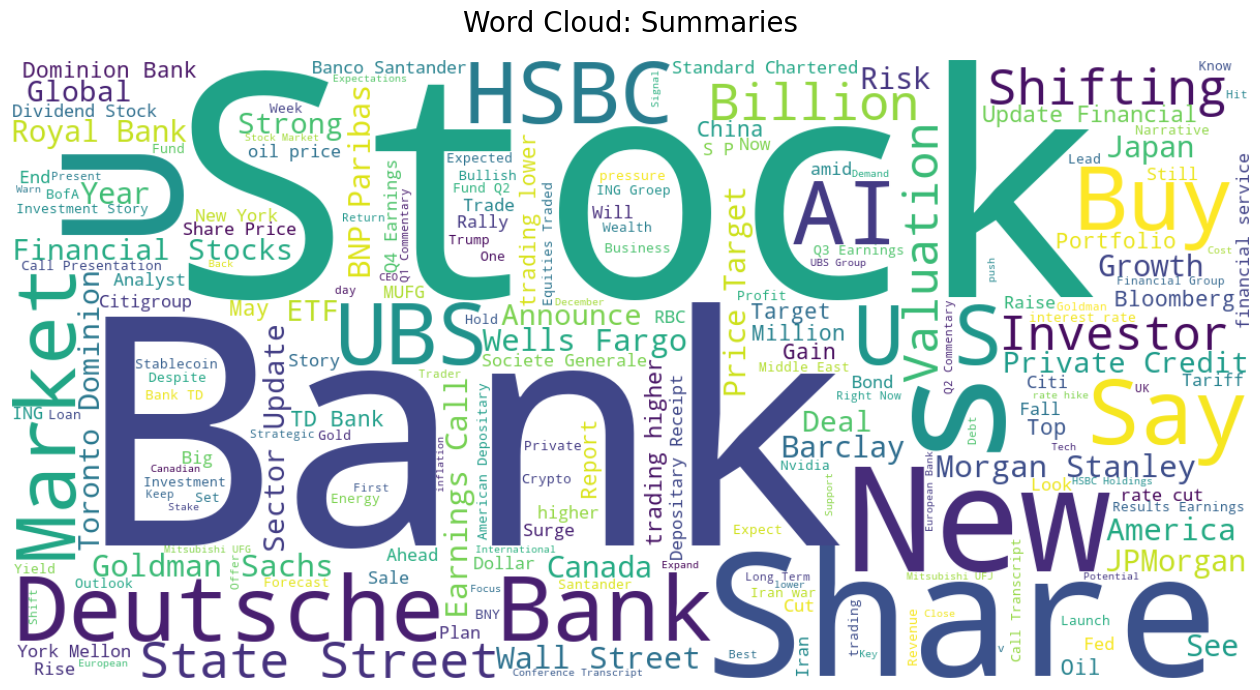

In [15]:
# Clean and extract keywords from titles
def extract_keywords(text):
    if pd.isna(text):
        return []
    # Convert to lowercase and extract words
    words = re.findall(r'\b[a-z]{2,}\b', str(text).lower())
    # Remove common stop words
    stop_words = {'we', 'il', 'll', 'as', 'it', 'vs', 'at', 'be', 'our', 'use', 'or', 'let', 'but', 'us', 'by', 'more', 'come', 'have', 'the', 'and', 'for', 'with', 'how', 'your', 'using', 'from', 'into', 'this', 'that', 'are', 'was', 'you', 'what', 'can', 'in', 'to', 'of', 'is', 'an', 'the', 'do', 'de', 'on', 'not', 'why', 'will'}
    return [w for w in words if w not in stop_words]


# Extract all keywords from titles
all_summary_words = []
for summary in finnhub_data['headline'].dropna():
    all_summary_words.extend(extract_keywords(summary))

# Count keyword frequency
summary_word_freq = Counter(all_summary_words)
top_summary_words = pd.DataFrame(summary_word_freq.most_common(20), 
                                columns=['keyword', 'frequency'])

# Bar chart of top keywords
fig2 = px.bar(top_summary_words, 
              x='keyword', 
              y='frequency',
              title='Top 20 Keywords in Summaries',
              labels={'keyword': 'Keyword', 'frequency': 'Frequency'},
              color='frequency',
              color_continuous_scale='Viridis')
fig2.update_layout(showlegend=False, height=500)
fig2.show(renderer = 'iframe')

# Word cloud for titles
print("\nGenerating word cloud for summaries...")
title_text = ' '.join(finnhub_data['headline'].dropna().astype(str))
wordcloud_title = WordCloud(width=1200, height=600, background_color='white', 
                             colormap='viridis').generate(title_text)
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud_title, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Summaries', fontsize=20, pad=20)
plt.tight_layout()
plt.show()